# Rerun models to finalize results
## Feeding and Non-feeding model 

#### TO DO:

NO DETECTRON
Frozen resnet - cross validation
Unfreeze the final few layers - no cross validation
Validation loss curves, make sure they look ok
Cross validation on slightly unfrozen resnet (e.g. 5 layers) or stop after a certain number of epochs after which overfitting

Save the model, save the data

WITH DETECTRON
Increase number of photos and see now accuracy changes (all non-detectron)
Increase number of photos but all additional photos are detectron (to same thresholds as before)



In [41]:
import tensorflow as tf
import os
import numpy as np
from matplotlib import pyplot as plt
import random
import pandas as pd

In [43]:
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [45]:
# Avoid OOM errors by setting GPU Memory Consumption Growth 

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

# Load and Configure Data

In [47]:
### Set the working directory to the directory containing your images

os.chdir('/Volumes/JulieBackup/2024MachineLearning/')

In [49]:
# The ResNet50 model expects images to be 224x224, so we set those values here
img_height, img_width = (224,224)
batch_size = 32

In [51]:
# Replace the path & file names with proper paths 
#train_df = pd.read_csv('Training.csv')
#test_df = pd.read_csv('Testing2.csv')

all_df = pd.read_csv('DataFilenamesRedo.csv')

In [52]:
os.chdir('/Volumes/JulieBackup/2024MachineLearning/Redo Data/')

## ONLY REAL PHOTOS

In [115]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming 'all_df' has a column 'photo_type' that indicates 'real' or 'superimposed'
real_df = all_df[all_df['photo_type'] == 'real']
#super_df = all_df[all_df['photo_type'] == 'super']

# Splitting real_df into train and test (80% for training and 20% for testing)
train_real_df, test_real_df = train_test_split(real_df, test_size=0.2, random_state=42)

# Randomly sampling 500 photos from super_df for training
#train_super_df = super_df.sample(n=500, random_state=42)

# Combining the real and superimposed training data
#train_df = pd.concat([train_real_df, train_super_df])
train_df = train_real_df

# The test set will be the remaining 20% of real_df
test_df = test_real_df

# Optional: Shuffle the training data after combining
#train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [17]:
# Set the working directory to the directory containing images (if different from where csv stored)
#os.chdir('/Volumes/JulieBackup/2024MachineLearning/flower v butterfly/Random names')


In [117]:
# preprocess_input gets your images in the format expected by the ResNet50 model
# horizontal_flip is an augmentation that will randomly flip your training image horizontally, thus increasing the variation in your training data
# You can add additional augmentations if you'd like (zoom, rotations, shear, etc.), but we're keeping it simple for now

#preprocessing_function = preprocess_input makes images turn blocky neon colours

train_datagen = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   horizontal_flip = True,
                                   shear_range = 0.2
                                  )

# We don't add augmentations to the test data to ensure it is representative of "real" data
test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input
                                  #rescale=1./255
                                 )


In [139]:
# Replace x_col and y_col refer to the column names of your filename and label columns
# If they are different from what I have here ("filename" and "label"), change them to whatever you named yours
# This is also where your images will be scaled to 224x224 pixels
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = 'filename',
    y_col = 'label',
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    seed = 123,
    shuffle = True
)

# Same as above but for your test dataset
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'filename',
    y_col = 'label',
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    seed = 123,
    shuffle = False
)

Found 3272 validated image filenames belonging to 2 classes.
Found 819 validated image filenames belonging to 2 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


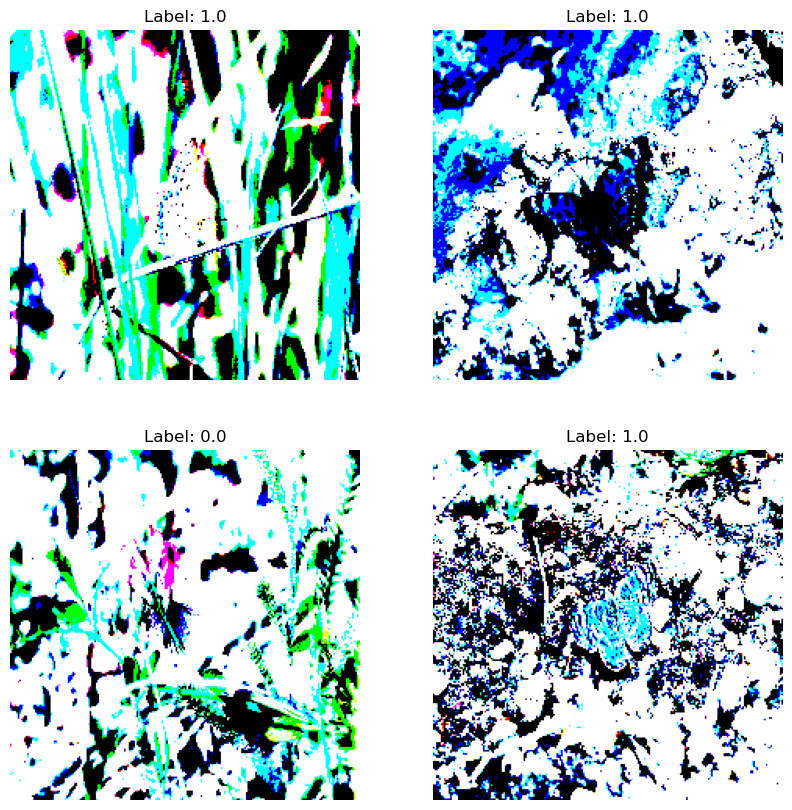

In [23]:
#check to see photos are normal

# Assuming images were normalized to [0, 1]
images, labels = next(train_generator)

# Plot the first 4 images from the batch
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    #rgb_image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    #plt.imshow(rgb_image)
    plt.imshow(images[i])
    plt.title(f'Label: {labels[i]}')
    plt.axis('off')
plt.show()

# Create model

In [55]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import random

In [57]:
#set seed so its always the same
seed_value= 321

os.environ['PYTHONHASHSEED']=str(seed_value)
 
random.seed(seed_value)

np.random.seed(seed_value)

tf.random.set_seed(seed_value)

In [59]:
# The code in my tutorial had a few additional layers, but I would try this out too. Sometimes simpler is better
base_model = ResNet50(include_top = False, weights = 'imagenet')
x = base_model.output

#add layers, but could overfit

#x = Dense(256, activation='relu', kernel_regularizer=l2(0.1))(x)

#change from 0.1 to 0.2 to 0.5 to reduce overfitting
#x = Dropout(0.1)(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation = 'sigmoid')(x)
#predictions = Dense(len(train_generator.class_indices), activation = 'softmax')(x)

model = Model(inputs = base_model.input, outputs = predictions)

#len(train_generator.class_indices)

In [61]:
#for layer in base_model.layers:
    # You can try setting this value to true, especially if you use the simpler architecture that I have above
    # Your model will probably take longer to train, but you might get better accuracy
    # layer.trainable = False
#unfreeze
for layer in base_model.layers:
        if "conv5_block" in layer.name: #tune just the final block ~15-20 layers
            layer.trainable = True
        else:
            layer.trainable = False

# If you're only training your model for ~20 epochs, setting early stopping isn't really necessary
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# This will make sure you save the model with the best validation set loss
#change name based on what I'm running
checkpoint = ModelCheckpoint('Real_Feeding_unfrozen_noxval.keras', monitor='val_loss', save_best_only=True)

# If you have 2 classes, set the loss here loss = 'binary_crossentropy'
# The style you did in your original code works too. I don't think there is a functional difference
# loss = 'categorical_crossentropy' is for multiclass (>2) models

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# Run model

In [129]:
# Set the epochs to however many you want
history = model.fit(train_generator, 
          epochs = 40,
          validation_data = test_generator,
          callbacks = [early_stopping, checkpoint])

Epoch 1/40


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


103/103 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.8868 - loss: 0.2681 - val_accuracy: 0.9231 - val_loss: 3.8738
Epoch 2/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.9773 - loss: 0.0683 - val_accuracy: 0.9328 - val_loss: 2.5982
Epoch 3/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.9829 - loss: 0.0492 - val_accuracy: 0.9719 - val_loss: 0.2396
Epoch 4/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9822 - loss: 0.0477 - val_accuracy: 0.9524 - val_loss: 0.3717
Epoch 5/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.9914 - loss: 0.0383 - val_accuracy: 0.9597 - val_loss: 0.2485
Epoch 6/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9897 - loss: 0.0254 - val_accuracy: 0.9621 - val_loss: 0.2682
Epoch 7/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9953 - loss: 0.0171 - val_accuracy: 0.9670 - val_loss: 0.2243
Epoch 8/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9939 - loss: 0.0187 - val_accuracy: 0.967

# K fold cross validation

In [63]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [67]:
y = all_df['label'].values

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(y) # F=1 and B=0

X = all_df['filename'].values

In [69]:
accuracy_per_fold = []
loss_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_per_fold = []

In [71]:
# Example of a simple data generator setup
datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

checkpoint = ModelCheckpoint('Real_Feeding_unfrozen_xval.keras', monitor='val_loss', save_best_only=True)


for train_idx, val_idx in kfold.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Create dataframes for training and validation
    train_df = pd.DataFrame({'filename': X_train, 'label': y_train})
    val_df = pd.DataFrame({'filename': X_val, 'label': y_val})

    # Create generators
    train_generator = datagen.flow_from_dataframe(
        train_df,
        x_col='filename',
        y_col='label',
        target_size = (img_height, img_width),
        batch_size = batch_size,
        class_mode = 'binary',
        seed = 123
    )

    val_generator = datagen.flow_from_dataframe(
        val_df,
        x_col='filename',
        y_col='label',
        target_size = (img_height, img_width),
        batch_size = 1,
        class_mode = 'binary',
        shuffle = False,
        seed = 123
    )

    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=[early_stopping, checkpoint]
    )

    #check accuracy metrics

    # Evaluate model on validation data
    val_predictions = model.predict(val_generator)
    val_predictions = (val_predictions > 0.5).astype(int)

    val_labels = val_generator.classes

    accuracy = accuracy_score(val_labels, val_predictions)
    precision = precision_score(val_labels, val_predictions)
    recall = recall_score(val_labels, val_predictions)
    f1 = f1_score(val_labels, val_predictions)
    loss = model.evaluate(val_generator, verbose=0)[0]

    accuracy_per_fold.append(accuracy)
    precision_per_fold.append(precision)
    recall_per_fold.append(recall)
    f1_per_fold.append(f1)
    loss_per_fold.append(loss)

    print(f'Fold completed. Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Loss: {loss:.4f}')

    # Reload model weights for the next fold
    # ask why this line is included
    #model.load_weights('best_weights_ResNet50_binary_superimposed2.keras')


Found 3800 validated image filenames belonging to 2 classes.
Found 950 validated image filenames belonging to 2 classes.
Epoch 1/10


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


119/119 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.8730 - loss: 0.3906 - val_accuracy: 0.9221 - val_loss: 0.9031
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9667 - loss: 0.0955 - val_accuracy: 0.9474 - val_loss: 0.4004
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.9852 - loss: 0.0470 - val_accuracy: 0.9463 - val_loss: 0.2827
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.9878 - loss: 0.0412 - val_accuracy: 0.9432 - val_loss: 0.4162
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 311s 3s/step - accuracy: 0.9921 - loss: 0.0305 - val_accuracy: 0.9295 - val_loss: 0.5860
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 303s 3s/step - accuracy: 0.9845 - loss: 0.0421 - val_accuracy: 0.9379 - val_loss: 0.2713
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 332s 3s/step - accuracy: 0.9936 - loss: 0.0196 - val_accuracy: 0.9463 - val_loss: 0.3168
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.949

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


119/119 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9802 - loss: 0.0732 - val_accuracy: 0.9789 - val_loss: 0.3091
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9905 - loss: 0.0270 - val_accuracy: 0.9905 - val_loss: 0.0314
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.9947 - loss: 0.0118 - val_accuracy: 0.9958 - val_loss: 0.0151
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.9958 - val_loss: 0.0090
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.9943 - loss: 0.0279 - val_accuracy: 0.9958 - val_loss: 0.0141
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9975 - loss: 0.0052 - val_accuracy: 0.9937 - val_loss: 0.0203
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.9663 - val_loss: 0.1078
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.9966 - loss: 0.0099 - val_accuracy: 0.958

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - accuracy: 0.9927 - loss: 0.0292 - val_accuracy: 0.9737 - val_loss: 0.0953
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 0.9968 - val_loss: 0.0069
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9963 - loss: 0.0101 - val_accuracy: 0.9979 - val_loss: 0.0076
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.9983 - loss: 0.0046 - val_accuracy: 0.9979 - val_loss: 0.0047
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9966 - loss: 0.0063 - val_accuracy: 0.9979 - val_loss: 0.0082
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.9982 - loss: 0.0037 - val_accuracy: 0.9979 - val_loss: 0.0084
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.9988 - loss: 0.0031 - val_accuracy: 0.9968 - val_loss: 0.0127
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.9939 - loss: 0.0151 - val_accuracy: 0.991

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


119/119 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.9955 - loss: 0.0126 - val_accuracy: 0.9947 - val_loss: 0.0094
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.9899 - loss: 0.0304 - val_accuracy: 0.9842 - val_loss: 0.0517
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.9935 - loss: 0.0149 - val_accuracy: 0.9926 - val_loss: 0.0139
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9947 - val_loss: 0.0176
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9985 - loss: 0.0034 - val_accuracy: 0.9874 - val_loss: 0.0379
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.9982 - loss: 0.0043 - val_accuracy: 0.9937 - val_loss: 0.0181
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.9987 - loss: 0.0018 - val_accuracy: 0.9937 - val_loss: 0.0234
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9987 - loss: 0.0028 - val_accuracy: 0.990

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


119/119 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.9958 - loss: 0.0162 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9976 - loss: 0.0057 - val_accuracy: 0.9979 - val_loss: 0.0040
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.9976 - loss: 0.0051 - val_accuracy: 0.9811 - val_loss: 0.0598
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9946 - loss: 0.0080 - val_accuracy: 0.9958 - val_loss: 0.0133
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9981 - loss: 0.0049 - val_accuracy: 0.9979 - val_loss: 0.0111
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9969 - loss: 0.0051 - val_accuracy: 0.9958 - val_loss: 0.0115
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9957 - loss: 0.0107 - val_accuracy: 0.9979 - val_loss: 0.0079
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9959 - loss: 0.0158 - val_accuracy: 0.993

In [73]:

# Convert lists to numpy arrays for easier computation
accuracy_per_fold = np.array(accuracy_per_fold)
precision_per_fold = np.array(precision_per_fold)
recall_per_fold = np.array(recall_per_fold)
f1_per_fold = np.array(f1_per_fold)
loss_per_fold = np.array(loss_per_fold)

# Print averages and standard deviations
print("Cross-Validation Results (5 folds):")
print(f"Accuracy: {accuracy_per_fold.mean():.4f} ± {accuracy_per_fold.std():.4f}")
print(f"Precision: {precision_per_fold.mean():.4f} ± {precision_per_fold.std():.4f}")
print(f"Recall: {recall_per_fold.mean():.4f} ± {recall_per_fold.std():.4f}")
print(f"F1 Score: {f1_per_fold.mean():.4f} ± {f1_per_fold.std():.4f}")
print(f"Loss: {loss_per_fold.mean():.4f} ± {loss_per_fold.std():.4f}")


Cross-Validation Results (5 folds):
Accuracy: 0.9836 ± 0.0168
Precision: 0.9858 ± 0.0149
Recall: 0.9844 ± 0.0177
F1 Score: 0.9851 ± 0.0152
Loss: 0.0780 ± 0.0979


# Plot and evaluate

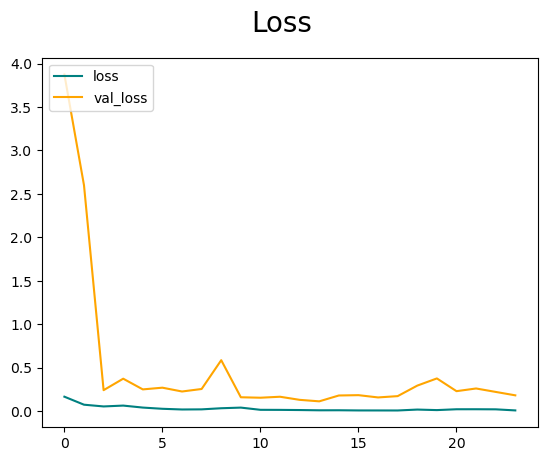

In [131]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

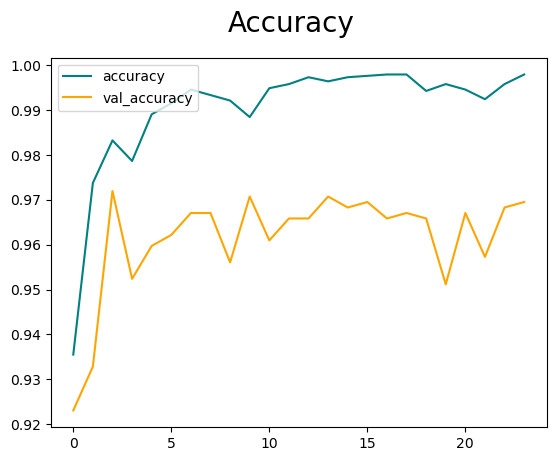

In [133]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")  
plt.show()

In [135]:
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, auc, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [137]:
test_generator = val_generator

In [141]:
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

valid_loss, valid_acc = model.evaluate(test_generator, verbose = 1) 

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 791ms/step - accuracy: 0.9663 - loss: 0.2180


In [142]:
print(valid_loss, valid_acc)

0.18008853495121002 0.9694749712944031


In [143]:
preds = model.predict(test_generator)

26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 776ms/step


In [144]:
predicted_classes = (preds > 0.5).astype(int).flatten()  # Flatten in case preds is a 2D array

true_classes = test_generator.classes

report = classification_report(true_classes, 
                               predicted_classes, 
                               output_dict=True)

macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1_score = report['macro avg']['f1-score']

print(f"Macro Precision: {macro_precision}")
print(f"Macro Recall: {macro_recall}")
print(f"Macro F1-Score: {macro_f1_score}")

conf_matrix = confusion_matrix(true_classes, predicted_classes)
print(conf_matrix)

Macro Precision: 0.9693071690844519
Macro Recall: 0.9690869272237197
Macro F1-Score: 0.9691955641612393
[[436  12]
 [ 13 358]]


In [55]:
# Initialize a counter for false positives and an empty list for filenames and labels
false_positive_count = 0
false_positive_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    if true == 0 and pred == 1:  # Check if actual is 0 (f) and predicted is 1 (nf)
        false_positive_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label'] 
        false_positive_details.append((filename, label))

# Print the manual false positive count
print(f"Manual False Positive Count: {false_positive_count}")

# Print the filenames and labels of the false positives
print("False Positive Filenames and Labels:")
for filename, label in false_positive_details:
    print(f"Filename: {filename}, Label: {label}")


Manual False Positive Count: 6
False Positive Filenames and Labels:
Filename: 4SYbGSoBx9.jpg, Label: F
Filename: wc0IubxTwt.jpg, Label: F
Filename: Bewa6EDPn3.jpg, Label: F
Filename: lrnF2tFjcT.jpg, Label: F
Filename: XL4LHss68M.jpg, Label: F
Filename: jWajomKOef.jpg, Label: F


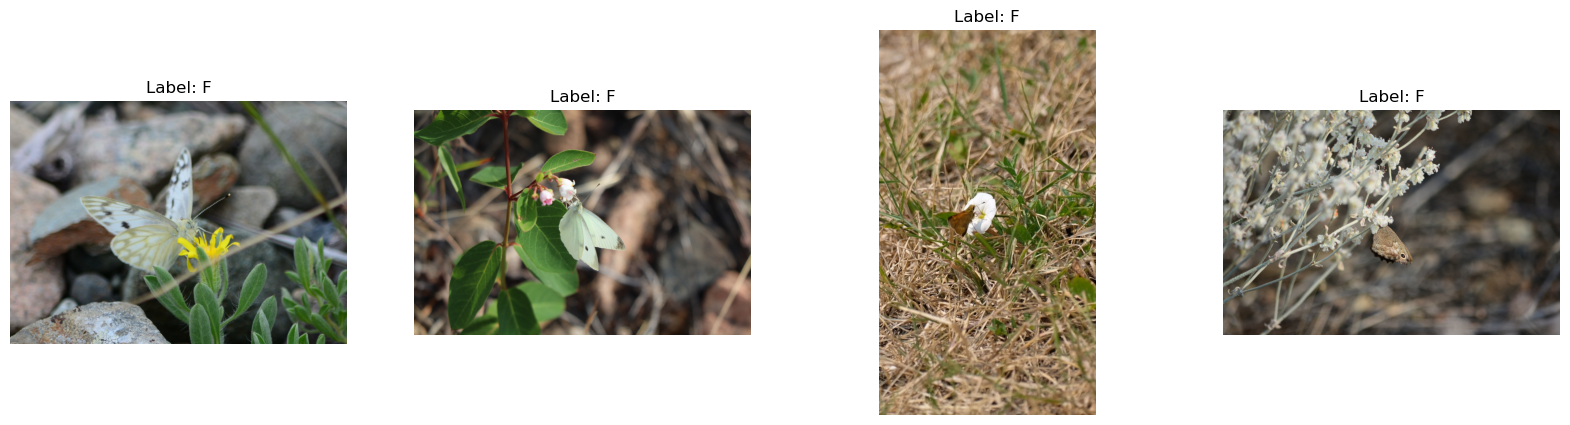

In [57]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Initialize a counter for false positives and an empty list for filenames and labels
false_positive_count = 0
false_positive_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    if true == 0 and pred == 1:  # Check if actual is 0 (f) and predicted is 1 (nf)
        false_positive_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label'] 
        false_positive_details.append((filename, label))

# Randomly select 4 images from the false positives
random_false_positives = random.sample(false_positive_details, 4)

# Set up the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Iterate through the randomly selected images
for ax, (filename, label) in zip(axes, random_false_positives):
    # Load and plot the image
    img = Image.open(filename)  # Assuming 'filename' contains the path to the image
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {label}")

# Display the plot
plt.show()


In [59]:
# Initialize a counter for false negatives and an empty list for filenames and labels
false_negative_count = 0
false_negative_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    if true == 1 and pred == 0:  # Check if actual is 1 (nf) and predicted is 0 (f)
        false_negative_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label'] 
        false_negative_details.append((filename, label))

# Print the manual false negative count
print(f"Manual False Negative Count: {false_negative_count}")

# Print the filenames and labels of the false negatives
print("False Negative Filenames and Labels:")
for filename, label in false_negative_details:
    print(f"Filename: {filename}, Label: {label}")



Manual False Negative Count: 28
False Negative Filenames and Labels:
Filename: 2inS4KhrNI.jpg, Label: N
Filename: H2pE4vxL22.jpg, Label: N
Filename: qNsN3XTtBh.jpg, Label: N
Filename: coG0vqdcxX.jpg, Label: N
Filename: p7IShpYDSu.jpg, Label: N
Filename: 4wkKPPKN3K.jpg, Label: N
Filename: YRkytjfcOj.jpg, Label: N
Filename: ce5BX4Gqpa.jpg, Label: N
Filename: oaZP6lHsom.jpg, Label: N
Filename: 712Hi5Vj1S.jpg, Label: N
Filename: mt01xzp6p4.jpg, Label: N
Filename: nCoGDSoUUP.jpg, Label: N
Filename: 4KzH8YOz5Y.jpg, Label: N
Filename: xixF8aQRdV.jpg, Label: N
Filename: 5KBkzgMwEV.jpg, Label: N
Filename: cKYSdEfLtp.jpg, Label: N
Filename: PZls3ih3VU.jpg, Label: N
Filename: qSnTn8ycgT.jpg, Label: N
Filename: YqvEbJQhUw.jpg, Label: N
Filename: fmPMVdcRzT.jpg, Label: N
Filename: CGCNQRrGvo.jpg, Label: N
Filename: ZokyZIq3SI.jpg, Label: N
Filename: TUZ3CodNMe.jpg, Label: N
Filename: KbIheF4xxU.jpg, Label: N
Filename: o78IwHtH9j.jpg, Label: N
Filename: ooC6XxL9my.jpg, Label: N
Filename: knvB4EDkj0.

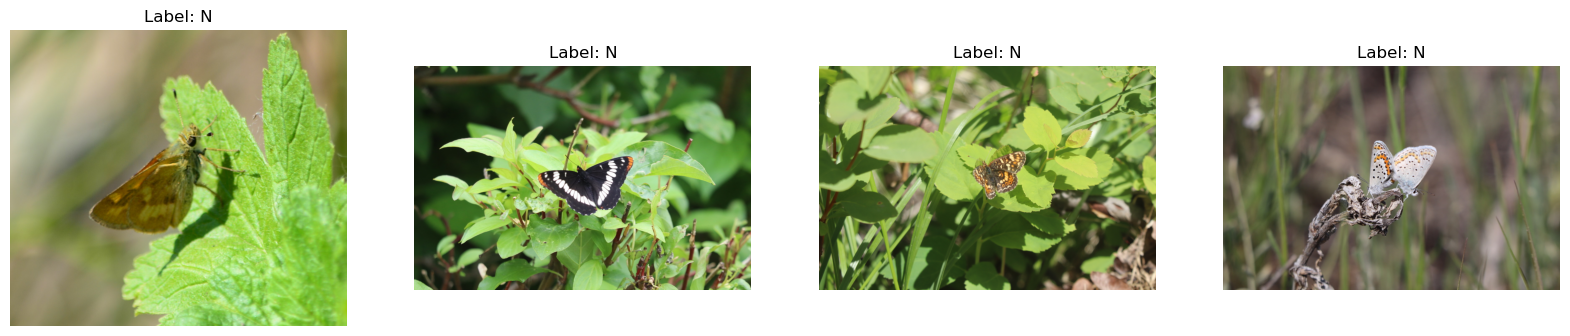

In [61]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Randomly select 4 images from the false negatives
random_false_negatives = random.sample(false_negative_details, 4)

# Set up the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Iterate through the randomly selected images
for ax, (filename, label) in zip(axes, random_false_negatives):
    # Load and plot the image
    img = Image.open(filename)  # Assuming 'filename' contains the path to the image
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {label}")

# Display the plot
plt.show()


In [58]:
# Initialize a counter for true positives and an empty list for filenames and labels
true_positive_count = 0
true_positive_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    if true == 1 and pred == 1:
        true_positive_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label']  # Assuming 'label' is the column name for labels
        true_positive_details.append((filename, label))

# Print the manual true positive count
print(f"Manual True Positive Count: {true_positive_count}")

# Print the filenames and labels of the true positives
print("True Positive Filenames and Labels:")
for filename, label in true_positive_details:
    print(f"Filename: {filename}, Label: {label}")


Manual True Positive Count: 90
True Positive Filenames and Labels:
Filename: 0p3KQGVMbN.jpg, Label: nf
Filename: 12NDas21jv.jpg, Label: nf
Filename: 2Dmr9ZCAqq.jpg, Label: nf
Filename: 2qsPbobEhO.jpg, Label: nf
Filename: 2sw8QudSEc.jpg, Label: nf
Filename: 3gDQHRnnHu.jpg, Label: nf
Filename: 3McPn2JWVe.jpg, Label: nf
Filename: 3y1AvLosxL.jpg, Label: nf
Filename: 3yPP7Uny0r.jpg, Label: nf
Filename: 4GaIQECohC.jpg, Label: nf
Filename: 6keiwKEtfW.jpg, Label: nf
Filename: 7UycPmjxky.jpg, Label: nf
Filename: 91qbfsh85B.jpg, Label: nf
Filename: 95VlvCseou.jpg, Label: nf
Filename: 9daRHk4cK5.jpg, Label: nf
Filename: 9lIWnCxlz3.jpg, Label: nf
Filename: avwSgJFf1y.jpg, Label: nf
Filename: b1E6YjV0Vw.jpg, Label: nf
Filename: bAzBekQcQs.jpg, Label: nf
Filename: BwxM5kbch4.jpg, Label: nf
Filename: BXRByDwIYh.jpg, Label: nf
Filename: c3I1Q72NY7.jpg, Label: nf
Filename: c49ofm0byd.jpg, Label: nf
Filename: CF2yFM5r37.jpg, Label: nf
Filename: cXwV4Ijprm.jpg, Label: nf
Filename: D96rmFWTnw.jpg, Label: 

In [60]:
# Initialize a counter for true negatives and an empty list for filenames and labels
true_negative_count = 0
true_negative_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true_label, pred_label) in enumerate(zip(true_classes, predicted_classes)):
    if true_label == 0 and pred_label == 0:  # Check if both actual and predicted labels are 0 (f)
        true_negative_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label'] 
        true_negative_details.append((filename, label))

# Print the manual true negative count
print(f"Manual True Negative Count: {true_negative_count}")

# Print the filenames and labels of the true negatives
print("True Negative Filenames and Labels:")
for filename, label in true_negative_details:
    print(f"Filename: {filename}, Label: {label}")


Manual True Negative Count: 2779
True Negative Filenames and Labels:
Filename: 00FVLlRN4c.jpg, Label: f
Filename: 03o2Vm6k49.jpg, Label: f
Filename: 06wUxwgKEH.jpg, Label: f
Filename: 0A5g9CDtGA.jpg, Label: f
Filename: 0BI0IGWhHd.jpg, Label: f
Filename: 0bvLxG55x5.jpg, Label: f
Filename: 0c3JdNInIv.jpg, Label: f
Filename: 0DeCUTS4oE.jpg, Label: f
Filename: 0DrP0jAArJ.jpg, Label: f
Filename: 0E19bg9ITV.jpg, Label: f
Filename: 0G7WFATUO3.jpg, Label: f
Filename: 0goyvvcfD9.jpg, Label: f
Filename: 0HmTkV3BmG.jpg, Label: f
Filename: 0ijdvWUxSC.jpg, Label: f
Filename: 0in8NTPAxv.jpg, Label: f
Filename: 0jGorZVeM6.jpg, Label: f
Filename: 0llqM6ABUg.jpg, Label: f
Filename: 0LzqFwM3vI.jpg, Label: f
Filename: 0MljARXQpc.jpg, Label: f
Filename: 0mtvAyg2JZ.jpg, Label: f
Filename: 0ngOJNQn2E.jpg, Label: f
Filename: 0NHgwugR2R.jpg, Label: f
Filename: 0NuFKC9h22.jpg, Label: f
Filename: 0Nv3bGmWmx.jpg, Label: f
Filename: 0NxfemUwKB.jpg, Label: f
Filename: 0osoyc0SX5.jpg, Label: f
Filename: 0OyeXFUAPE.

# Test on brand new images

In [8]:
from tensorflow.keras.models import load_model

In [10]:
os.chdir('/Volumes/JulieBackup/2024MachineLearning/Redo Data/')

In [12]:
model = load_model(os.path.join('ResNet50_detectall_kfold2.keras'))

In [13]:
os.chdir('/Volumes/JulieBackup/2024MachineLearning/')

In [16]:
test_df = pd.read_csv('BIMBY_redo.csv')

In [18]:
os.chdir('//Users/juliesieg/Documents/2024 BIMBY/')

In [20]:
test_datagen = ImageDataGenerator(preprocessing_function =  preprocess_input
                                  #rescale=1./255
                                 )

In [26]:
# Same as above but for your test dataset
test_generator = test_datagen.flow_from_dataframe(
    dataframe = test_df,
    x_col = 'filename',
    y_col = 'label',
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    seed = 123,
    shuffle = False
)

Found 3261 validated image filenames belonging to 2 classes.


/opt/anaconda3/lib/python3.11/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [28]:
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, auc, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [30]:
def custom_data_generator(generator):
    for i in range(len(generator)):
        try: 
            batch_x, batch_y = generator[i]
        except Exception as e:
            print(f"Error with batch {i}: {e}")
            print(f"Processing files: {generator.filenames[i * generator.batch_size : (i + 1) * generator.batch_size]}")
            raise e  # Re-raise the exception after logging
        yield batch_x, batch_y

# Use the custom generator
test_generator_with_tracking = custom_data_generator(test_generator)

# Now evaluate the model using the custom generator to catch the problematic image
valid_loss, valid_acc = model.evaluate(test_generator_with_tracking, verbose=1)


     64/Unknown 60s 930ms/step - accuracy: 0.8920 - loss: 0.5458

KeyboardInterrupt: 

In [87]:
# List of filenames that caused the error
error_batch_filenames = [
    'hvnGPxYc2j.jpg', 'HvQXlzuAS2.jpg', 'HvrQ8NPBE3.jpg', 'hXBVAcYhBz.jpg', 
    'HXLsj3iGKL.jpg', 'HXm97arhGI.jpg', 'HXMoBGJAUL.jpg', 'HYN2RJsqyl.jpg', 
    'hYNRXudiQG.jpg', 'hYqs6X9BME.jpg', 'hYSYo3xQzS.jpg', 'hyxOJAaGW6.jpg', 
    'hznXZB6eNZ.jpg', 'HzwvM2DfUS.jpg', 'I0CojjUqL2.jpg', 'i0DMGRG2BG.jpg', 
    'i0tmU6Vr8n.jpg', 'i15lLz7TJu.jpg', 'i3dQ1J5ybR.jpg', 'I3Dtw0YDlP.jpg', 
    'i3eyEgzVgt.jpg', 'I3kxtTBxLZ.jpg', 'I4JiT2Mrzj.jpg', 'i5j9WMjlS3.jpg', 
    'I5rNmz89gQ.jpg', 'I5vt7QZhOT.jpg', 'I8PCkDnqgZ.jpg', 'I9LWh8pmb9.jpg', 
    'I9ypWU0miw.jpg', 'ia7wktYjAe.jpg', 'iaN7ACgbMn.jpg', 'iANHoaDhSB.jpg'
]

for filename in error_batch_filenames:
    try:
        img = Image.open(filename)  # Adjust path if necessary
        img.verify()  # Check if the image is valid
        print(f"{filename} is valid.")
    except (IOError, SyntaxError) as e:
        print(f"Corrupted image file: {filename}")

hvnGPxYc2j.jpg is valid.
HvQXlzuAS2.jpg is valid.
HvrQ8NPBE3.jpg is valid.
hXBVAcYhBz.jpg is valid.
HXLsj3iGKL.jpg is valid.
HXm97arhGI.jpg is valid.
HXMoBGJAUL.jpg is valid.
HYN2RJsqyl.jpg is valid.
hYNRXudiQG.jpg is valid.
hYqs6X9BME.jpg is valid.
hYSYo3xQzS.jpg is valid.
hyxOJAaGW6.jpg is valid.
hznXZB6eNZ.jpg is valid.
HzwvM2DfUS.jpg is valid.
I0CojjUqL2.jpg is valid.
i0DMGRG2BG.jpg is valid.
i0tmU6Vr8n.jpg is valid.
i15lLz7TJu.jpg is valid.
i3dQ1J5ybR.jpg is valid.
I3Dtw0YDlP.jpg is valid.
i3eyEgzVgt.jpg is valid.
I3kxtTBxLZ.jpg is valid.
I4JiT2Mrzj.jpg is valid.
i5j9WMjlS3.jpg is valid.
I5rNmz89gQ.jpg is valid.
I5vt7QZhOT.jpg is valid.
I8PCkDnqgZ.jpg is valid.
I9LWh8pmb9.jpg is valid.
I9ypWU0miw.jpg is valid.
ia7wktYjAe.jpg is valid.
iaN7ACgbMn.jpg is valid.
iANHoaDhSB.jpg is valid.


In [62]:
# Print the number of validated images found
print(f"Number of testing images found: {test_generator.samples}") 

# Print the number of images of each class for testing data
print("Testing class indices: ", test_generator.class_indices)
print("Testing labels count: ", test_df['label'].value_counts())

Number of testing images found: 3261
Testing class indices:  {'f': 0, 'nf': 1}
Testing labels count:  label
f     3075
nf     188
Name: count, dtype: int64


In [38]:
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

valid_loss, valid_acc = model.evaluate(test_generator, verbose = 1)

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8906 - loss: 0.5543


In [39]:
from PIL import Image
import os

folder_path = '/Volumes/JulieBackup/2024MachineLearning/2024 BIMBY/'
for subdir, dirs, files in os.walk(folder_path):
    for file in files:
        file_path = os.path.join(subdir, file)
        try:
            img = Image.open(file_path)
            img.verify()  # Check if the image is complete
        except (IOError, SyntaxError) as e:
            print(f"Corrupted image file: {file_path}")

In [40]:
print(valid_loss, valid_acc)

0.6431740522384644 0.8690585494041443


In [41]:
preds = model.predict(test_generator)

102/102 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step


In [64]:
predicted_classes = (preds > 0.3).astype(int).flatten()  # Flatten in case preds is a 2D array

true_classes = test_generator.classes

report = classification_report(true_classes, 
                               predicted_classes, 
                               output_dict=True)

macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1_score = report['macro avg']['f1-score']

print(f"Macro Precision: {macro_precision}")
print(f"Macro Recall: {macro_recall}")
print(f"Macro F1-Score: {macro_f1_score}")

conf_matrix = confusion_matrix(true_classes, predicted_classes)
print(conf_matrix)

Macro Precision: 0.5916772750011894
Macro Recall: 0.7201423170925909
Macro F1-Score: 0.6139459711939355
[[2677  396]
 [  81  107]]


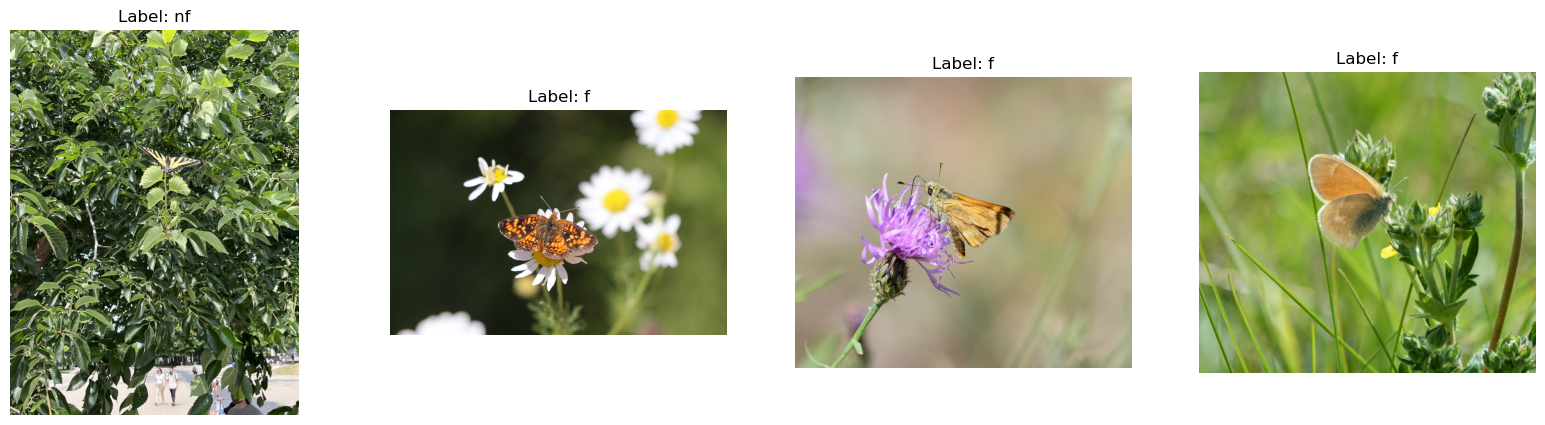

In [107]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Initialize a counter for false positives and an empty list for filenames and labels
false_positive_count = 0
false_positive_details = []

# Iterate through the true and predicted classes, along with the filenames
for i, (true, pred) in enumerate(zip(true_classes, predicted_classes)):
    if true == 0 and pred == 1:  # Check if actual is 0 (f) and predicted is 1 (nf)
        false_positive_count += 1
        # Get the corresponding filename and label
        filename = test_df.iloc[i]['filename']
        label = test_df.iloc[i]['label'] 
        false_positive_details.append((filename, label))

# Randomly select 4 images from the false positives
random_false_positives = random.sample(false_positive_details, 4)

# Set up the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Iterate through the randomly selected images
for ax, (filename, label) in zip(axes, random_false_positives):
    # Load and plot the image
    img = Image.open(filename)  # Assuming 'filename' contains the path to the image
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {label}")

# Display the plot
plt.show()


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Randomly select 4 images from the false negatives
random_false_negatives = random.sample(false_negative_details, 4)

# Set up the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Iterate through the randomly selected images
for ax, (filename, label) in zip(axes, random_false_negatives):
    # Load and plot the image
    img = Image.open(filename)  # Assuming 'filename' contains the path to the image
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {label}")

# Display the plot
plt.show()
